In [1]:
import numpy as np
import xarray as xr
import pyart
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Circle
import glob
import sys
import os
from grf_functions import *

plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=12)
rc('figure', facecolor='white')
rc('axes', titlesize=15)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# paths
dnogrf = "/data/arrcwx/wrt_jtrf/morton/no_grf/"
fnogrf = sorted(glob.glob(f"{dnogrf}DEALIASED*"))
dgrf = "/data/arrcwx/wrt_jtrf/morton/grf/bf2/"
fgrf = sorted(glob.glob(f"{dgrf}DEALIASED*"))
nfiles = len(fgrf)

# desired time
jt = 14

# read radar
rn = pyart.io.read(fnogrf[jt])
rg = pyart.io.read(fgrf[jt])

# vortex positions
dvort = "/data/arrcwx/wrt_jtrf/morton/sa/"
vffiles = sorted(glob.glob(f"{dvort}vortex*"))
vortex = np.loadtxt(vffiles[jt], delimiter=',', skiprows=1)
xv, yv = vortex[0], vortex[1]

In [23]:
# extract raw variables
x, y, z = rn.get_gate_x_y_z(0)
refn = rn.fields['DBZ_ADJ']['data']
veln = rn.fields['VEL']['data']
veldeln = rn.fields['VELDEL']['data']
sw = rn.fields['WIDTH']['data']
# rudimentary clutter mask
vmag = 3
swc = 3
cmask = (np.abs(veln) < vmag) & (sw < swc)
veln_masked = np.where(cmask, np.nan, veln)
veldeln_masked = np.where(cmask, np.nan, veldeln)
refn_masked = np.where(cmask, np.nan, refn)

# extract filtered variables
refg = rg.fields['DBZ_ADJ']['data']
velg = rg.fields['VEL']['data']
veldelg = rg.fields['VELDEL']['data']

tu = rn.time['units']
tplot = tu[14:-10] + " " + tu[-9:-1]

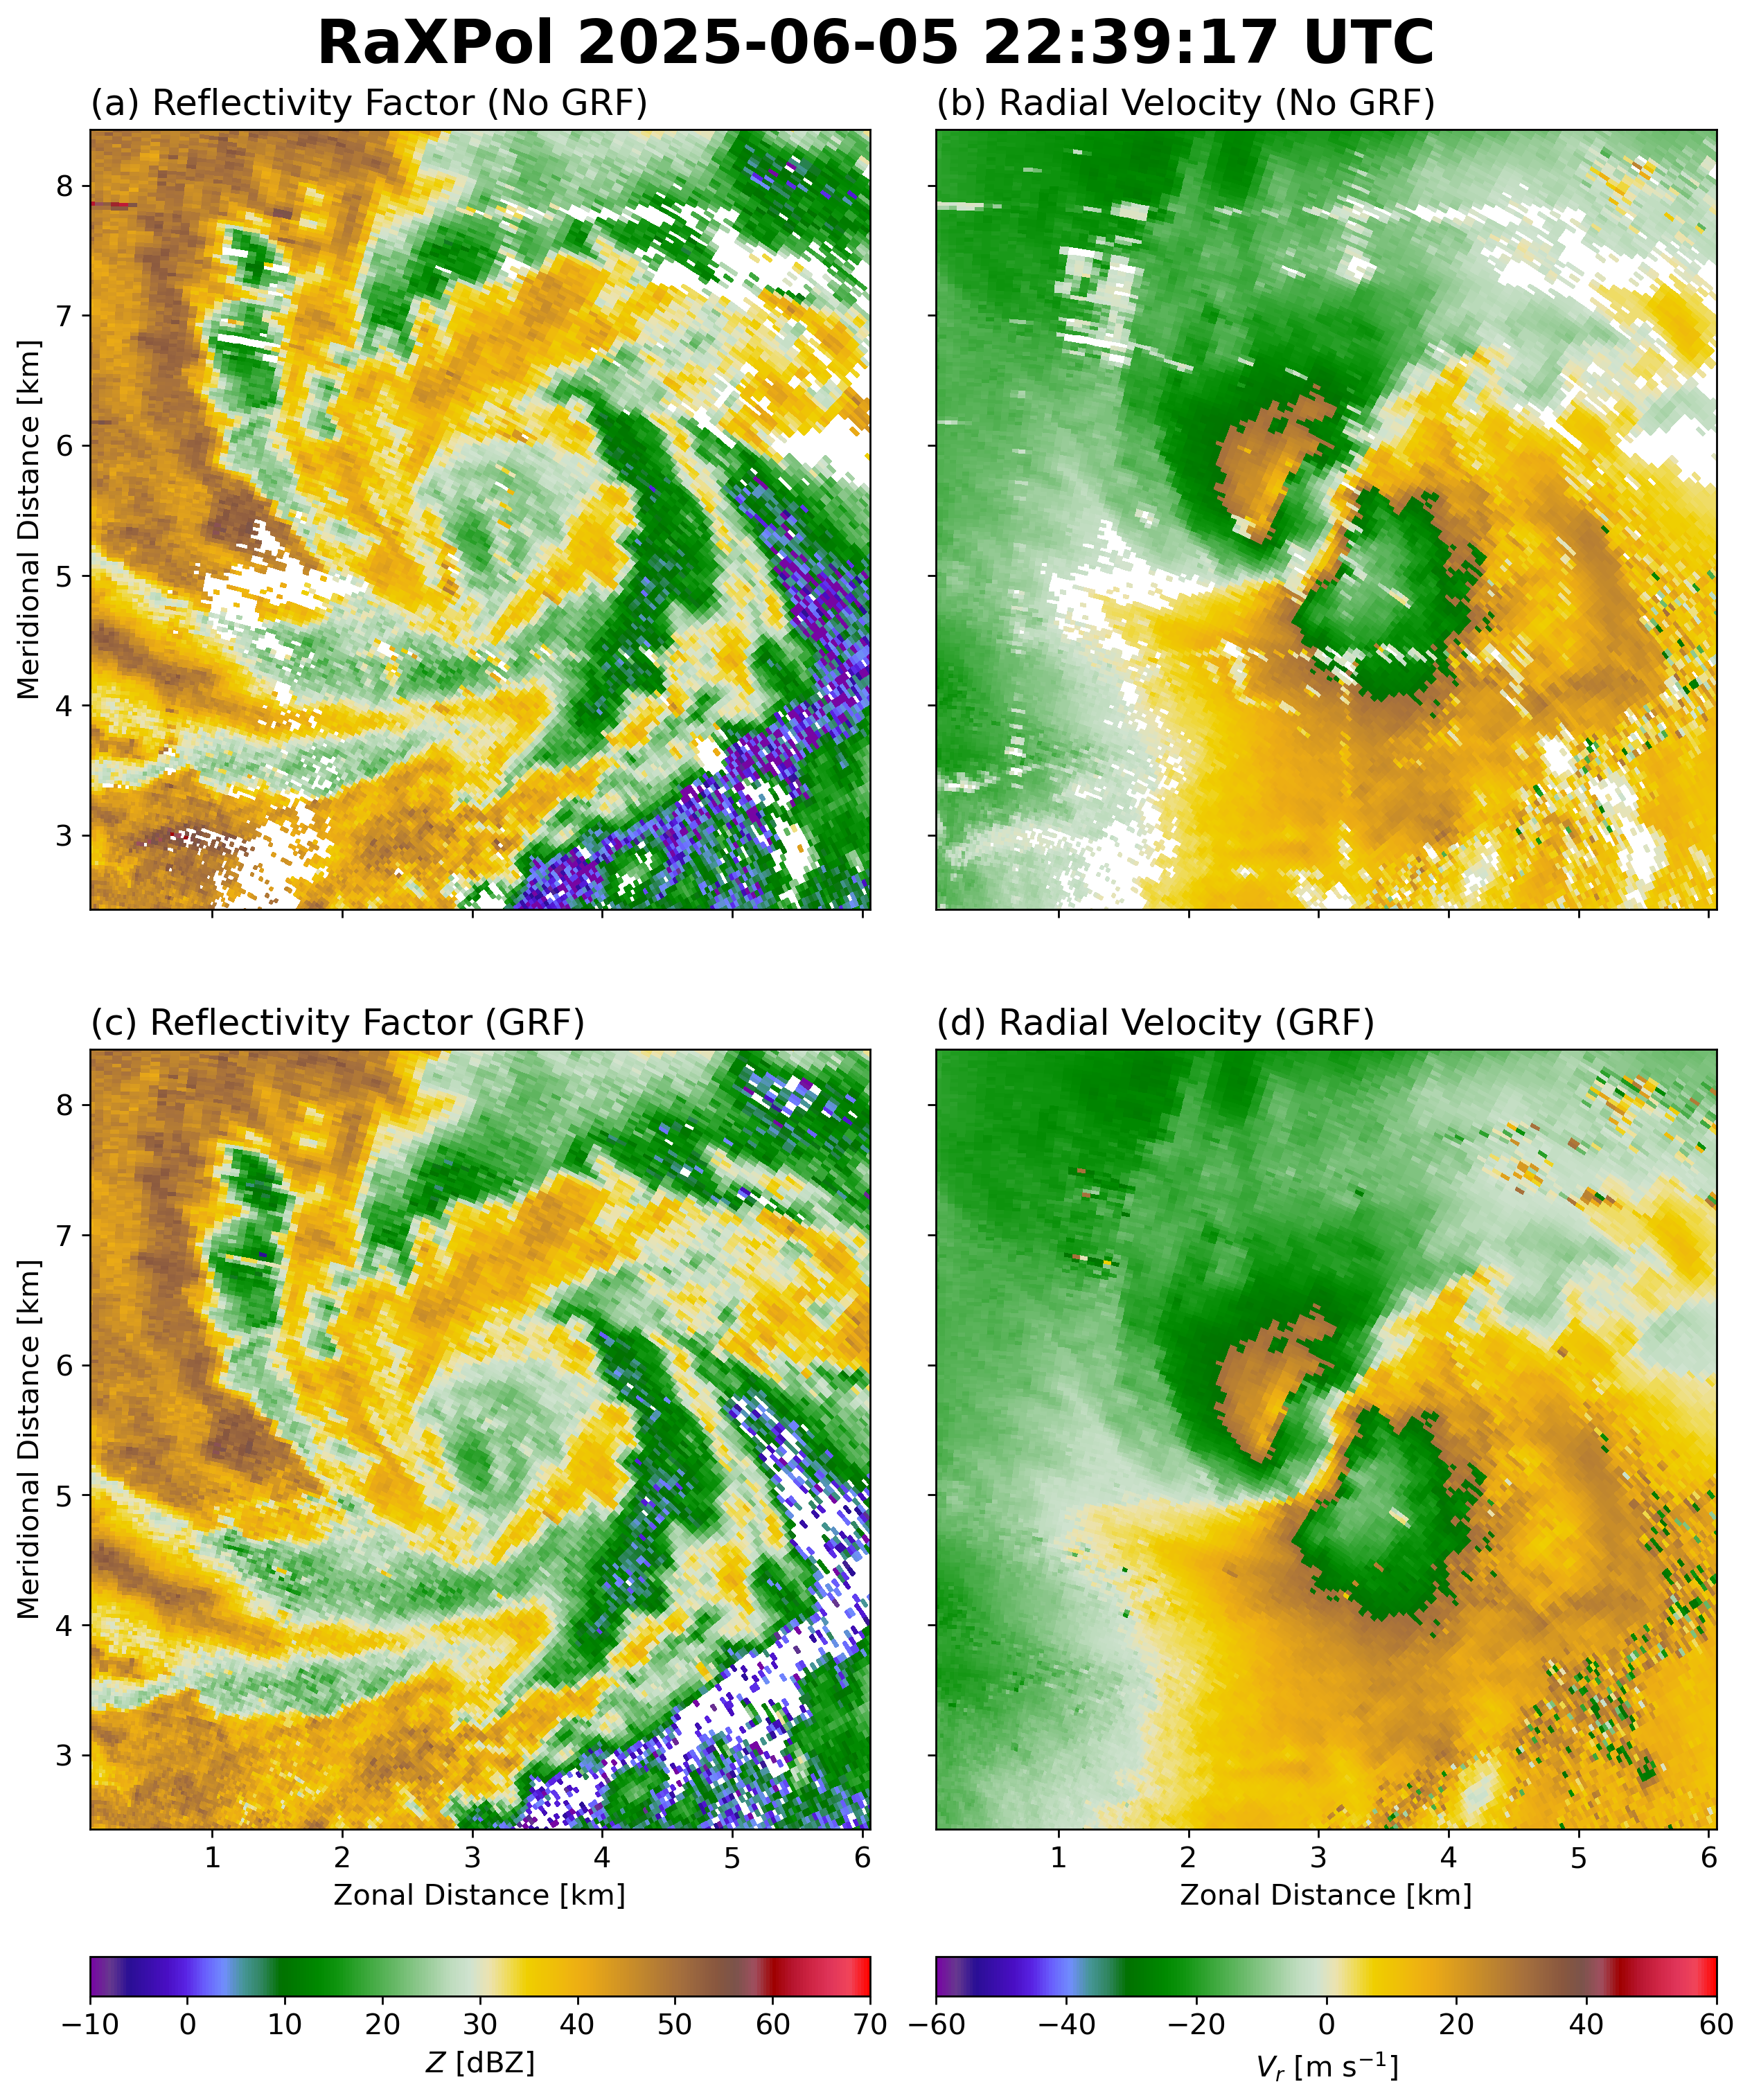

In [24]:
# figure
fig, axs = plt.subplots(
    figsize=(10,12),
    nrows=2,
    ncols=2,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=250
    )
fig.suptitle(f"RaXPol {tplot} UTC", fontsize=25, fontweight='bold')

# raw ref
ax = axs[0,0]
pcm = ax.pcolormesh(x/1e3, y/1e3, refn_masked,
                    vmin=-10, vmax=70,
                    cmap="Carbone42")
ax.set_title("(a) Reflectivity Factor (No GRF)", loc='left')
ax.set_ylabel("Meridional Distance [km]")
# raw velocity
ax = axs[0,1]
pcm = ax.pcolormesh(x/1e3, y/1e3, veln_masked,
                    vmin=-60, vmax=60,
                    cmap="Carbone42")
ax.set_title("(b) Radial Velocity (No GRF)", loc='left')

# filtered ref
ax = axs[1,0]
pcm = ax.pcolormesh(x/1e3, y/1e3, refg,
                    vmin=-10, vmax=70,
                    cmap="Carbone42")
ax.set_title("(c) Reflectivity Factor (GRF)", loc='left')
ax.set_ylabel("Meridional Distance [km]")
ax.set_xlabel("Zonal Distance [km]")
plt.colorbar(pcm, ax=ax, orientation="horizontal", label="$Z$ [dBZ]")
# filtered velocity
ax = axs[1,1]
pcm = ax.pcolormesh(x/1e3, y/1e3, velg,
                    vmin=-60, vmax=60,
                    cmap="Carbone42")
ax.set_title("(d) Radial Velocity (GRF)", loc='left')
ax.set_xlabel("Zonal Distance [km]")
plt.colorbar(pcm, ax=ax, orientation="horizontal", label="$V_r$ [m s$^{-1}$]")

# clean up
for ax in axs.flatten():
    ax.set_xlim(xv-3, xv+3)
    ax.set_ylim(yv-3, yv+3)
    ax.set_aspect('equal')

In [25]:
xc, yc = 3.21, 4.70
xw, yw = 3.5, 4.70

In [35]:
r = rn.range['data']/1e3
az = rn.azimuth['data']
# find r, az indices
rc = np.sqrt(xc**2 + yc**2)
rc_idx = np.argmin(np.abs(r-rc))
azc = np.rad2deg(np.arctan2(xc,yc)) % 360
azc_idx = np.argmin(np.abs(az-azc))

print(veln_masked[azc_idx, rc_idx])
print(veldeln_masked[azc_idx, rc_idx])

-9.06
52.555397073425674


In [36]:
print(velg[azc_idx, rc_idx])
print(veldelg[azc_idx, rc_idx])

-14.47
47.14539707342568


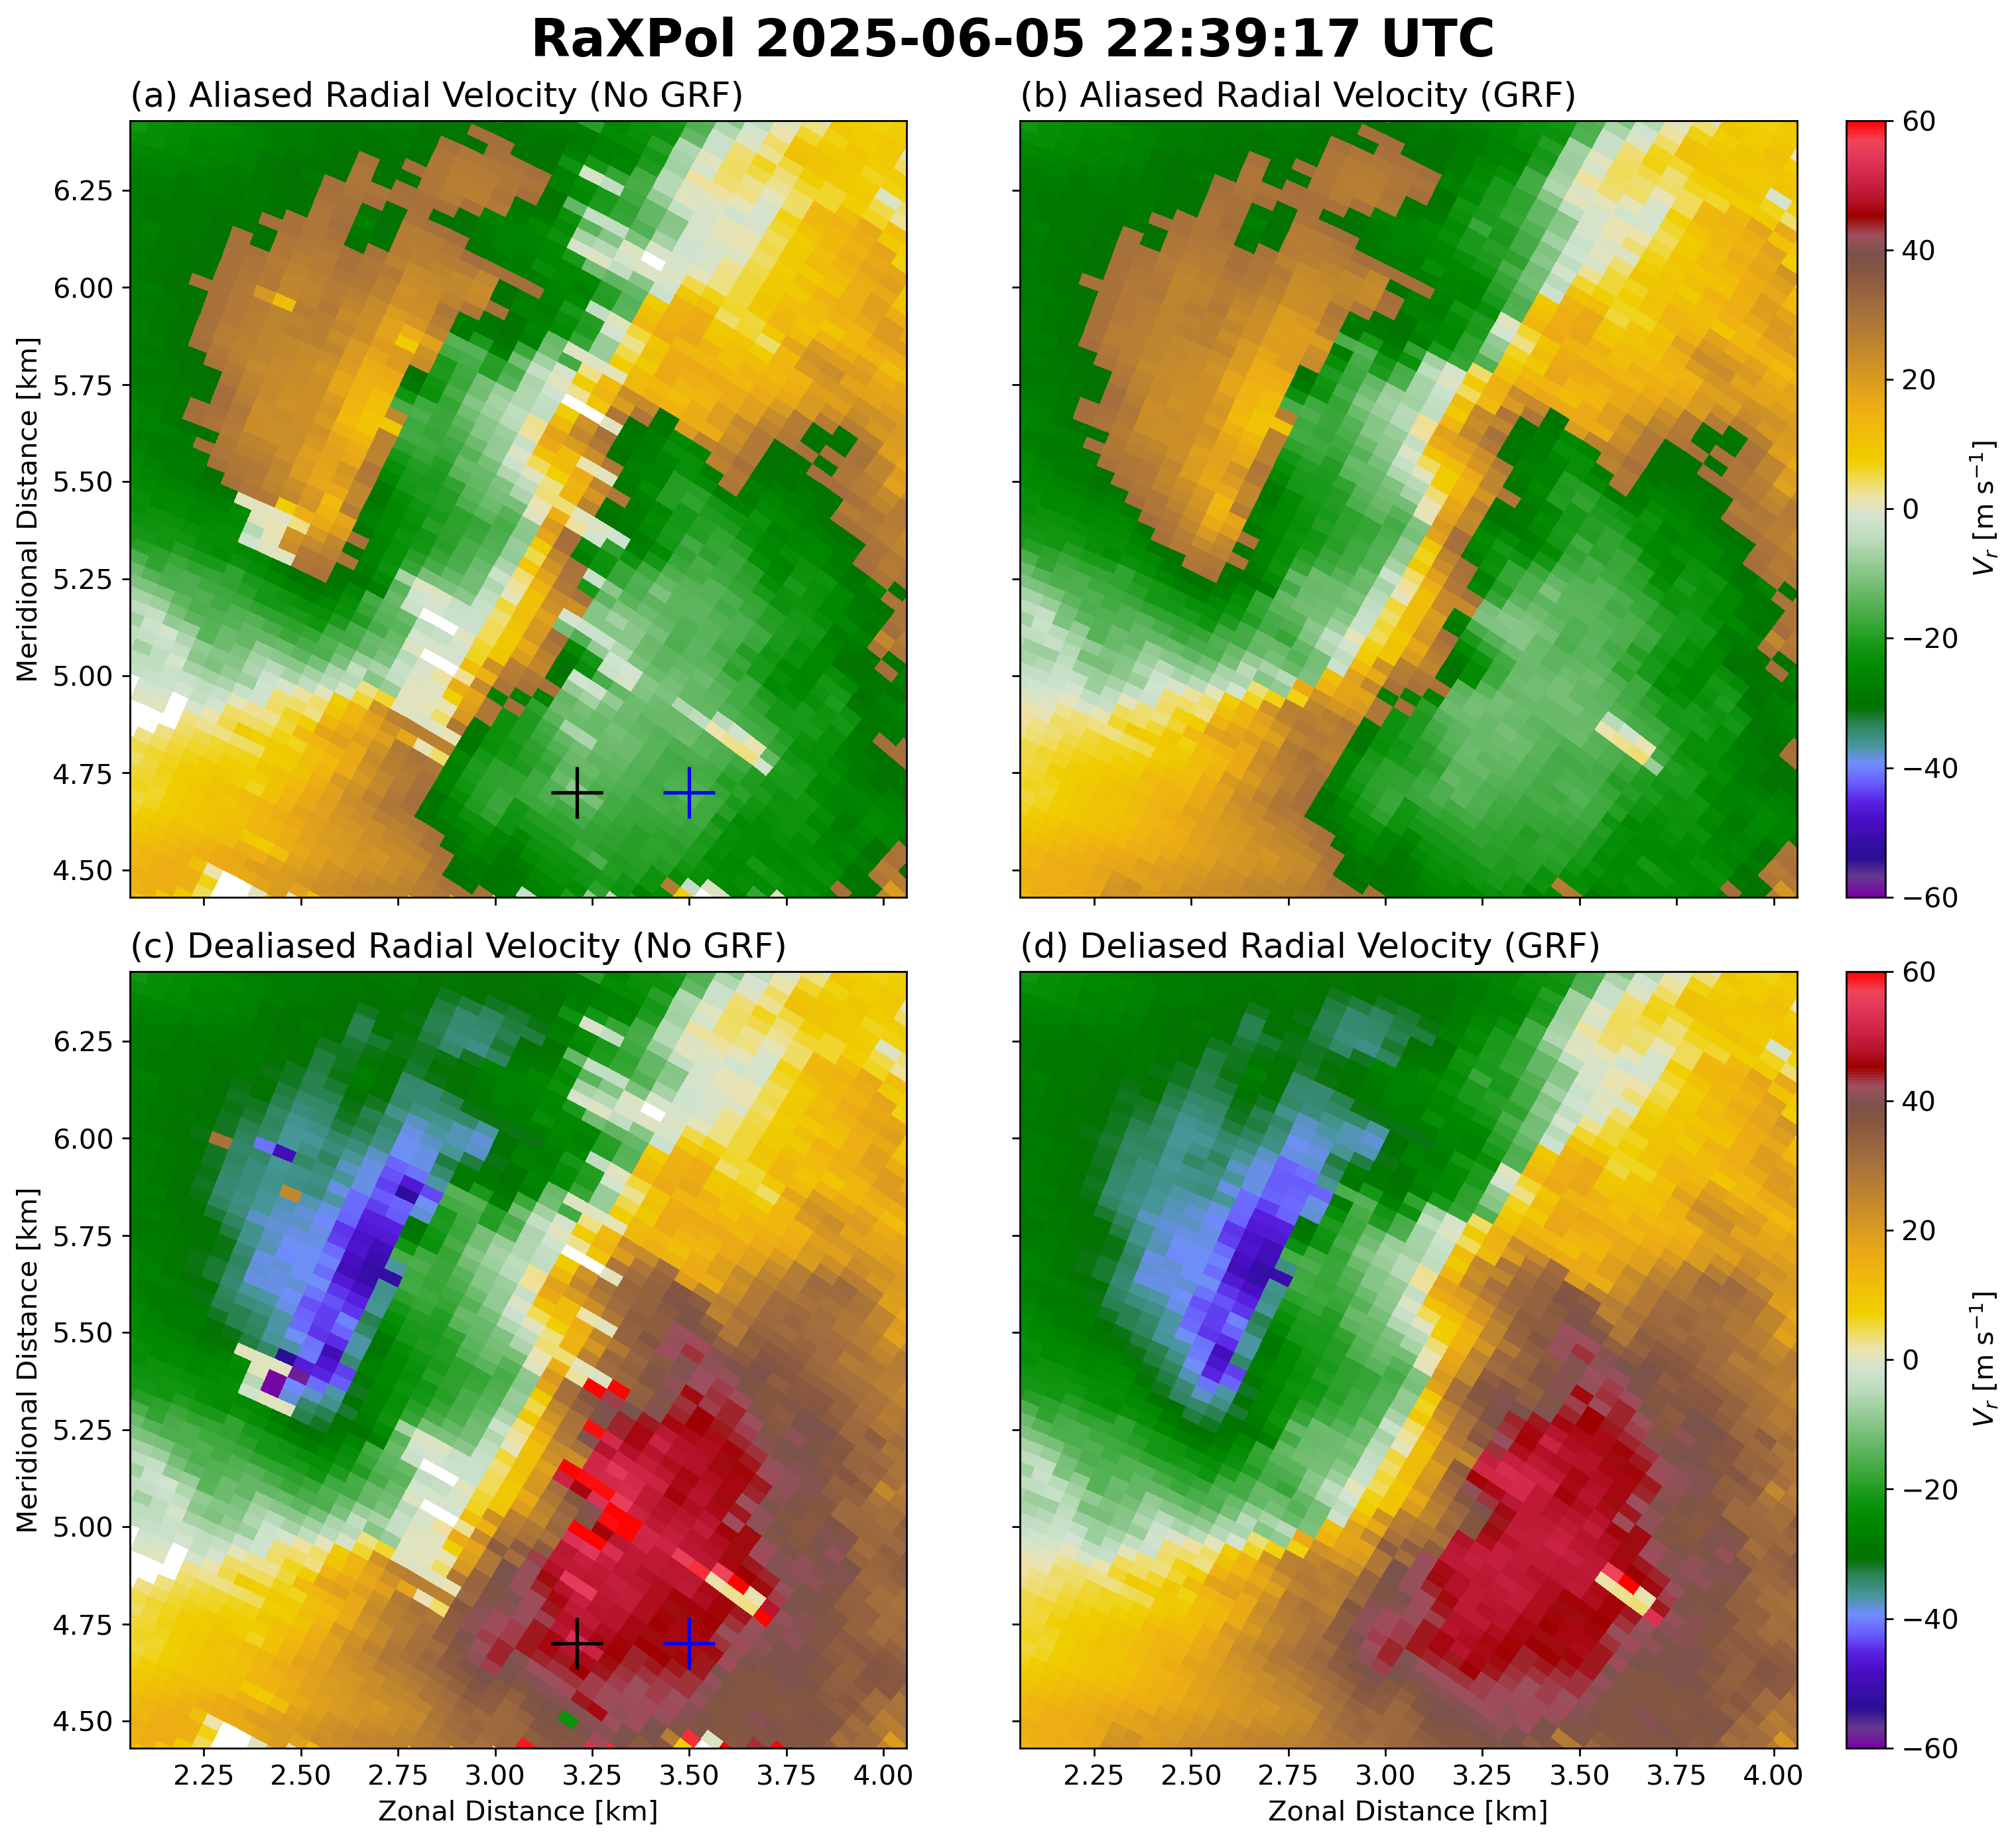

In [27]:
# figure
fig, axs = plt.subplots(
    figsize=(12,11),
    ncols=2,
    nrows=2,
    sharey=True,
    sharex=True,
    constrained_layout=True,
    dpi=250
    )
fig.suptitle(f"RaXPol {tplot} UTC", fontsize=22.5, fontweight='bold')

# raw velocity
ax = axs[0,0]
vmin, vmax = -60, 60
pcm = ax.pcolormesh(x/1e3, y/1e3, veln_masked,
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42")
ax.set_title("(a) Aliased Radial Velocity (No GRF)", loc='left')
ax.set_ylabel("Meridional Distance [km]")
# filtered velocity
ax = axs[0,1]
pcm = ax.pcolormesh(x/1e3, y/1e3, velg,
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42")
ax.set_title("(b) Aliased Radial Velocity (GRF)", loc='left')
plt.colorbar(pcm, ax=ax, orientation="vertical", label="$V_r$ [m s$^{-1}$]")

# raw dealiased velocity
ax = axs[1,0]
pcm = ax.pcolormesh(x/1e3, y/1e3, veldeln_masked,
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42")
ax.set_title("(c) Dealiased Radial Velocity (No GRF)", loc='left')
ax.set_ylabel("Meridional Distance [km]")
ax.set_xlabel("Zonal Distance [km]")
# filtered dealiased velocity
ax = axs[1,1]
pcm = ax.pcolormesh(x/1e3, y/1e3, veldelg,
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42")
ax.set_title("(d) Deliased Radial Velocity (GRF)", loc='left')
ax.set_xlabel("Zonal Distance [km]")
plt.colorbar(pcm, ax=ax, orientation="vertical", label="$V_r$ [m s$^{-1}$]")

# clean up
for ax in axs.flatten():
    ax.set_xlim(xv-1, xv+1)
    ax.set_ylim(yv-1, yv+1)
    ax.set_aspect('equal')
# plot spectra gates
for ax in axs[:,0]:
    ax.scatter(xc, yc, s=500, c='black', marker='+')
    ax.scatter(xw, yw, s=500, c='blue', marker='+')